# 🚀 Pipeline ETL & Inteligencia de Mercado — Food Delivery (USA)

**Módulo:** Python para Análisis de Datos (ETL)
**Rol asumido:** Data Engineer & Analista BI
**Autor:** _(Franchesco Edwin Ancco Mamani)_

## 🎯 Contexto de negocio

Una startup de *Food Delivery* busca expandirse en Estados Unidos. Antes de invertir en una
ciudad, el directorio necesita entender **cómo operan los competidores actuales**, **qué
categorías dominan el mercado** y **cómo se comportan los precios según la región**.

El equipo de Web Scraping entregó dos archivos crudos:

| Archivo | Descripción | Filas aprox. |
|---|---|---|
| `restaurants.csv` | Catálogo maestro de restaurantes (dirección concatenada, puntajes, rango de precios en símbolos `$`). | 63,000 |
| `restaurant-menus.csv` | Detalle de cada ítem del menú (nombre del plato, precio en texto). | 5,000,000 |

### 🏗️ Arquitectura del pipeline

1. **EXTRACT** → Lectura de los CSV con Pandas.
2. **TRANSFORM** → Limpieza de texto, split de columnas, mapeo de diccionarios, casteo numérico y reducción del dataset para cuidar la RAM.
3. **LOAD** → Carga del cruce final a una base SQLite local (`delivery_insights.db`) vía SQLAlchemy.
4. **BUSINESS INTELLIGENCE** → Consultas SQL + gráficos profesionales para responder las preguntas del CEO.


---
## 📦 FASE 1 — EXTRACT

Cargamos ambos datasets crudos y hacemos un **diagnóstico inicial (Data Profiling)** antes de
tocar una sola celda: dimensiones, tipos de dato y nulos por columna.

> ⚠️ **Nota:** `restaurant-menus.csv` (~5 millones de filas) viene partido en 10 archivos
> dentro de la carpeta `DATA/restaurant-menus.csv/` (`restaurant_menus_parte_1.csv` ...
> `restaurant_menus_parte_10.csv`) por el límite de tamaño de GitHub. Los unimos todos con
> `pd.concat()` antes de seguir. Este notebook asume que existe una carpeta `DATA/` en la
> misma ubicación que este archivo `.ipynb`, con la estructura tal como viene del repositorio.


In [2]:
# 📚 Librerías del proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import gc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [3]:
# 📥 Carga del catálogo de restaurantes (un solo archivo)
df_restaurantes = pd.read_csv("DATA/restaurants.csv/restaurants.csv")
print("df_restaurantes cargado:", df_restaurantes.shape)


df_restaurantes cargado: (63469, 11)


In [4]:
# 📥 Carga del detalle de menús
# El archivo original (~5 millones de filas) viene partido en 10 CSV por el límite
# de tamaño de GitHub. Los unimos todos en un solo DataFrame con pd.concat().
import glob

archivos_menu = sorted(glob.glob("DATA/restaurant-menus.csv/*.csv"))
print(f"Archivos de menú detectados: {len(archivos_menu)}")

df_menus = pd.concat(
    (pd.read_csv(archivo) for archivo in archivos_menu),
    ignore_index=True,
)

print("df_menus cargado (unido):", df_menus.shape)


Archivos de menú detectados: 10
df_menus cargado (unido): (836350, 5)


In [5]:
# 🔍 Diagnóstico inicial — df_restaurantes
print("Dimensiones (filas, columnas):", df_restaurantes.shape)
print("\nTipos de dato:\n", df_restaurantes.dtypes)
print("\nValores nulos por columna:\n", df_restaurantes.isnull().sum())
df_restaurantes.head()


Dimensiones (filas, columnas): (63469, 11)

Tipos de dato:
 id                int64
position          int64
name             object
score           float64
ratings         float64
category         object
price_range      object
full_address     object
zip_code         object
lat             float64
lng             float64
dtype: object

Valores nulos por columna:
 id                  0
position            0
name                0
score           28167
ratings         28167
category           85
price_range     10617
full_address      453
zip_code          517
lat                 0
lng                 0
dtype: int64


,id,position,name,score,ratings,category,price_range,full_address,zip_code,lat,lng
0,1,19,PJ Fresh (224 Daniel Payne Drive),NaN,NaN,"Burgers, American, Sandwiches",$,"224 Daniel Payne Drive, Birmingham, AL, 35207",35207,33.562365,-86.830703
1,2,9,J' ti`'z Smoothie-N-Coffee Bar,NaN,NaN,"Coffee and Tea, Breakfast and Brunch, Bubble Tea",NaN,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",35217,33.583640,-86.773330
2,3,6,Philly Fresh Cheesesteaks (541-B Graymont Ave),NaN,NaN,"American, Cheesesteak, Sandwiches, Alcohol",$,"541-B Graymont Ave, Birmingham, AL, 35204",35204,33.509800,-86.854640
3,4,17,Papa Murphy's (1580 Montgomery Highway),NaN,NaN,Pizza,$,"1580 Montgomery Highway, Hoover, AL, 35226",35226,33.404439,-86.806614
4,5,162,Nelson Brothers Cafe (17th St N),4.7,22.0,"Breakfast and Brunch, Burgers, Sandwiches",NaN,"314 17th St N, Birmingham, AL, 35203",35203,33.514730,-86.811700


In [6]:
# 🔍 Diagnóstico inicial — df_menus
print("Dimensiones (filas, columnas):", df_menus.shape)
print("\nTipos de dato:\n", df_menus.dtypes)
print("\nValores nulos por columna:\n", df_menus.isnull().sum())
df_menus.head()


Dimensiones (filas, columnas): (836350, 5)

Tipos de dato:
 restaurant_id     int64
category         object
name             object
description      object
price            object
dtype: object

Valores nulos por columna:
 restaurant_id         0
category              0
name                  1
description      200324
price                 0
dtype: int64


,restaurant_id,category,name,description,price
0,1,Extra Large Pizza,Extra Large Meat Lovers,Whole pie.,15.99 USD
1,1,Extra Large Pizza,Extra Large Supreme,Whole pie.,15.99 USD
2,1,Extra Large Pizza,Extra Large Pepperoni,Whole pie.,14.99 USD
3,1,Extra Large Pizza,Extra Large BBQ Chicken &amp; Bacon,Whole Pie,15.99 USD
4,1,Extra Large Pizza,Extra Large 5 Cheese,Whole pie.,14.99 USD


---
## 🧹 FASE 2 — TRANSFORM

### 💲 2.1 Mapeo de rango de precios (`df_restaurantes`)

La columna de precios llega en símbolos (`$`, `$$`, `$$$`, `$$$$`). La traducimos a texto legible
para que el reporte final sea entendible por el directorio.


In [7]:
# 💲 Diccionario de traducción de precios
mapa_precios = {
    "$": "Económico",
    "$$": "Moderadamente caro",
    "$$$": "Caro",
    "$$$$": "Muy caro",
}

df_restaurantes["rango_de_precios"] = df_restaurantes["price_range"].map(mapa_precios)

df_restaurantes[["price_range", "rango_de_precios"]].drop_duplicates()


,price_range,rango_de_precios
0,$,Económico
1,NaN,NaN
5,$$,Moderadamente caro
15,$$$,Caro
1734,$$$$,Muy caro
45118,$$$$$$$$$$$$$$$$$,NaN


### 🏠 2.2 Desanidado de ubicaciones (Split)

La dirección completa viene concatenada: `calle, ciudad, estado codigo_postal`. La separamos en
tres columnas nuevas: `calle`, `ciudad` y `estado_zip`.


In [8]:
# 🏠 Split de la dirección completa en 3 columnas
# ⚠️ La dirección real trae 4 segmentos separados por coma (calle, ciudad, estado, zip).
# Usamos n=2 para limitar el split a 2 cortes: así el 3er trozo agrupa "estado, zip"
# tal como pide la consigna (calle | ciudad | estado_zip).
direccion_split = df_restaurantes["full_address"].str.split(",", n=2, expand=True)

df_restaurantes["calle"] = direccion_split[0].str.strip()
df_restaurantes["ciudad"] = direccion_split[1].str.strip()   # quitamos espacios ocultos
df_restaurantes["estado_zip"] = direccion_split[2].str.strip()

df_restaurantes[["full_address", "calle", "ciudad", "estado_zip"]].head()


,full_address,calle,ciudad,estado_zip
0,"224 Daniel Payne Drive, Birmingham, AL, 35207",224 Daniel Payne Drive,Birmingham,"AL, 35207"
1,"1521 Pinson Valley Parkway, Birmingham, AL, 35217",1521 Pinson Valley Parkway,Birmingham,"AL, 35217"
2,"541-B Graymont Ave, Birmingham, AL, 35204",541-B Graymont Ave,Birmingham,"AL, 35204"
3,"1580 Montgomery Highway, Hoover, AL, 35226",1580 Montgomery Highway,Hoover,"AL, 35226"
4,"314 17th St N, Birmingham, AL, 35203",314 17th St N,Birmingham,"AL, 35203"


### 🧽 2.3 Filtro de calidad y normalización de categorías

Eliminamos restaurantes sin puntaje (nulo) o con puntaje 0 — no aportan señal de calidad — y
estandarizamos `category` a minúsculas para evitar duplicados por mayúsculas/minúsculas.


In [9]:
# 🧽 Filtro de calidad: fuera restaurantes sin score o con score = 0
antes = df_restaurantes.shape[0]

df_restaurantes = df_restaurantes[df_restaurantes["score"].notna() & (df_restaurantes["score"] != 0)]
df_restaurantes["category"] = df_restaurantes["category"].str.lower()

despues = df_restaurantes.shape[0]
print(f"Restaurantes eliminados por score nulo/0: {antes - despues}")
print("Filas restantes:", despues)


Restaurantes eliminados por score nulo/0: 28167
Filas restantes: 35302


### 💵 2.4 Limpieza de precios en `df_menus`

El precio de cada ítem viene como texto, por ejemplo `"15,99 USD"`. Quitamos el sufijo `" USD"`,
reemplazamos la coma decimal por punto y lo casteamos a `float`. Luego descartamos ítems con
precio 0 o nulo (no representan una venta real).


In [10]:
# 💵 Limpieza y casteo de precios del menú
def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan
    return float(str(valor).replace(" USD", "").replace(",", "."))

df_menus["price"] = df_menus["price"].apply(limpiar_precio)

antes = df_menus.shape[0]
df_menus = df_menus[df_menus["price"].notna() & (df_menus["price"] != 0.0)]
despues = df_menus.shape[0]

print(f"Ítems de menú eliminados por precio nulo/0: {antes - despues}")
print("Filas restantes:", despues)
df_menus.dtypes


Ítems de menú eliminados por precio nulo/0: 37551
Filas restantes: 798799


restaurant_id      int64
category          object
name              object
description       object
price            float64
dtype: object

---
## 🧮 Optimización de memoria y cruce (Merge)

`restaurant-menus.csv` tiene ~5 millones de filas: cruzarlo contra **todos** los restaurantes
puede colapsar la RAM del servidor. El CEO solo necesita analizar los restaurantes
**consolidados**, así que primero filtramos y recién después hacemos el `merge`.


In [11]:
# 🧮 Filtro de optimización: solo restaurantes con más de 100 calificaciones
mem_antes = df_restaurantes.memory_usage(deep=True).sum() / 1_048_576
df_restaurantes_filtrado = df_restaurantes[df_restaurantes["ratings"] > 100].copy()
mem_despues = df_restaurantes_filtrado.memory_usage(deep=True).sum() / 1_048_576

print(f"Restaurantes antes del filtro: {df_restaurantes.shape[0]:,}")
print(f"Restaurantes consolidados (ratings > 100): {df_restaurantes_filtrado.shape[0]:,}")
print(f"Memoria antes: {mem_antes:.2f} MB  →  Memoria después: {mem_despues:.2f} MB")


Restaurantes antes del filtro: 35,302
Restaurantes consolidados (ratings > 100): 8,702
Memoria antes: 22.40 MB  →  Memoria después: 5.61 MB


In [12]:
# 🔗 INNER JOIN entre restaurantes consolidados y sus ítems de menú
df_master = pd.merge(
    df_restaurantes_filtrado,
    df_menus,
    left_on="id",
    right_on="restaurant_id",
    how="inner",
)

print("df_master:", df_master.shape)
df_master.head()


df_master: (63221, 20)


,id,position,name_x,score,ratings,category_x,price_range,full_address,zip_code,lat,lng,rango_de_precios,calle,ciudad,estado_zip,restaurant_id,category_y,name_y,description,price
0,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Spring Roll,"Three rolls. Shrimps, sliced pork, vermicelli ...",6.99
1,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Egg Roll,"Pork, carrot, bean thread noodles, and are wra...",6.50
2,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Grilled Pork,Foot long.,9.50
3,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,House Special,"Rice noodle with steak, rare, flank, brisket, ...",10.95
4,1739,21,Pho Cali Noodle House,4.4,200.0,"vietnamese, noodles, sandwich, asian",$,"4756 S 27th St, Milwaukee, WI, 53221",53221,42.958143,-87.94815,Económico,4756 S 27th St,Milwaukee,"WI, 53221",1739,Picked for you,Rice Noodle with Rare Steak,NaN,10.95


In [13]:
# 🧹 Liberamos memoria de DataFrames intermedios que ya no necesitamos
del df_restaurantes, df_menus, direccion_split
gc.collect()


3548

---
## 💾 FASE 3 — LOAD

Cargamos `df_master` en una base de datos SQLite local llamada `delivery_insights.db`, dentro
de la tabla `master_food_data`.


In [14]:
# 💾 Creación del motor SQLite y carga de la tabla final
engine = create_engine("sqlite:///delivery_insights.db")

df_master.to_sql(
    "master_food_data",
    con=engine,
    if_exists="replace",
    index=False,
)

print("✅ Tabla 'master_food_data' cargada en delivery_insights.db")


✅ Tabla 'master_food_data' cargada en delivery_insights.db


---
## 📊 FASE 4 — Business Intelligence: Reporte al CEO

Nos conectamos a `delivery_insights.db` y respondemos, con SQL + gráficos, las 4 preguntas
críticas del directorio.


In [15]:
conn = engine.connect()


### 1️⃣ Penetración geográfica

**¿Cuáles son las 5 ciudades con más restaurantes consolidados?**


In [16]:
query_1 = """
SELECT ciudad, COUNT(DISTINCT id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY ciudad
ORDER BY cantidad_restaurantes DESC
LIMIT 5;
"""

df_top_ciudades = pd.read_sql(text(query_1), conn)
print(query_1)
df_top_ciudades



SELECT ciudad, COUNT(DISTINCT id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY ciudad
ORDER BY cantidad_restaurantes DESC
LIMIT 5;



,ciudad,cantidad_restaurantes
0,Milwaukee,122
1,Seattle,119
2,Lynnwood,40
3,Everett,32
4,Bellevue,28


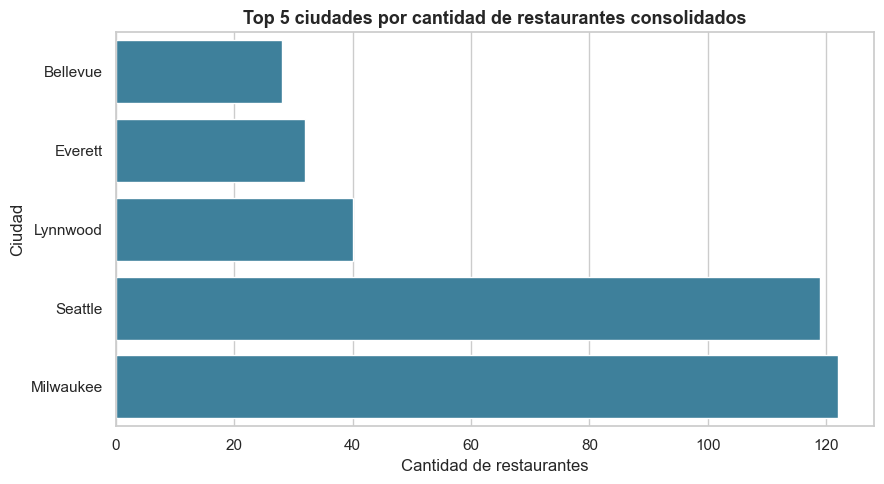

In [17]:
# 📊 Gráfico: barras horizontales ordenadas de mayor a menor
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=df_top_ciudades.sort_values("cantidad_restaurantes"),
    x="cantidad_restaurantes", y="ciudad",
    color="#2E86AB", ax=ax,
)
ax.set_title("Top 5 ciudades por cantidad de restaurantes consolidados", fontsize=13, fontweight="bold")
ax.set_xlabel("Cantidad de restaurantes")
ax.set_ylabel("Ciudad")
plt.tight_layout()
plt.show()


**Conclusión para el CEO:** Milwaukee (122) y Seattle (119) están prácticamente empatadas en primer lugar y juntas concentran el 71% de la competencia del top 5, mientras que Lynnwood, Everett y Bellevue apenas suman entre 28 y 40 restaurantes cada una. 
**Recomendación:** Iniciar la expansión en paralelo en Milwaukee y Seattle ambas ya tienen demanda validada por el mercado—, y usar Lynnwood como mercado secundario de bajo riesgo antes de considerar Everett o Bellevue, donde la oferta todavía es incipiente.

### 2️⃣ Análisis de oportunidad de precio

**¿Todos los restaurantes del mercado son caros?**


In [18]:
query_2 = """
SELECT rango_de_precios, COUNT(DISTINCT id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY cantidad_restaurantes DESC;
"""

df_dist_precios = pd.read_sql(text(query_2), conn)
print(query_2)
df_dist_precios



SELECT rango_de_precios, COUNT(DISTINCT id) AS cantidad_restaurantes
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY cantidad_restaurantes DESC;



,rango_de_precios,cantidad_restaurantes
0,Económico,450
1,Moderadamente caro,157
2,None,60
3,Caro,4


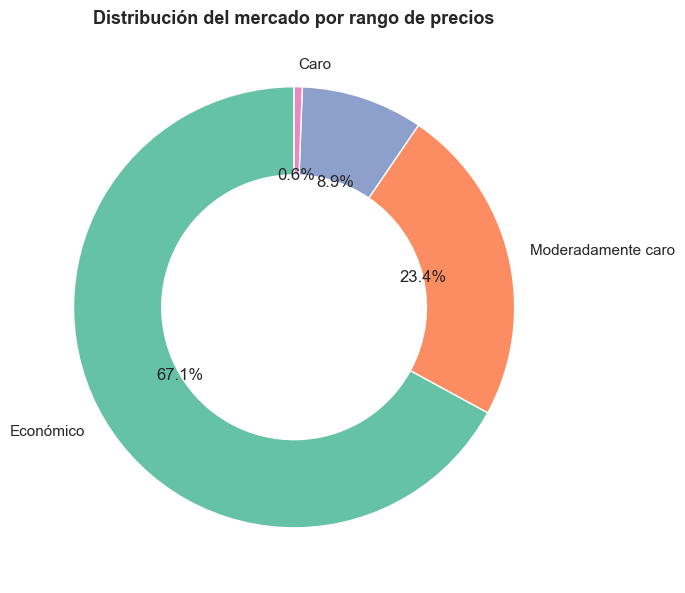

In [19]:
# 📊 Gráfico: donut chart
fig, ax = plt.subplots(figsize=(7, 7))
colores = sns.color_palette("Set2", len(df_dist_precios))
ax.pie(
    df_dist_precios["cantidad_restaurantes"],
    labels=df_dist_precios["rango_de_precios"],
    autopct="%1.1f%%",
    colors=colores,
    wedgeprops={"width": 0.4},
    startangle=90,
)
ax.set_title("Distribución del mercado por rango de precios", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Conclusión para el CEO:** el 67% de los restaurantes consolidados es Económico y solo 4 de 671 (0.6%) son Caros, así que la idea de que "todo el mercado es caro" no se sostiene la oportunidad real está en competir por volumen en el segmento accesible, no por margen premium. **Recomendación:** priorizar un catálogo de restaurantes económicos/moderados para captar la mayor parte del mercado, y no destinar presupuesto de adquisición a negociar con restaurantes premium, que son una porción marginal de la oferta.

⚠️ **Nota de calidad de datos:** detecté que el 8.9% de los restaurantes (60 de 671) no tiene un `price_range` reconocible en el gráfico aparecen como una porción sin etiqueta junto a "Caro". Antes de usar este gráfico en una decisión de inversión real, recomendaría auditar esos 60 registros en el dataset original, porque ahora mismo están inflando la incertidumbre del panorama de precios sin que se note a simple vista.

### 3️⃣ Estrategia de menú por ciudad
**En las 3 ciudades más populares, ¿en cuál es más caro comer en promedio?**


In [20]:
top_3_ciudades = df_top_ciudades["ciudad"].head(3).tolist()

# Armamos la clausula IN a mano para que funcione con cualquier cantidad de ciudades
# (una tupla de 1 elemento en Python genera una coma colgante que rompe el SQL)
ciudades_sql = ", ".join(f"'{ciudad}'" for ciudad in top_3_ciudades)

query_3 = f"""
SELECT ciudad, ROUND(AVG(price), 2) AS precio_promedio_plato
FROM master_food_data
WHERE ciudad IN ({ciudades_sql})
GROUP BY ciudad
ORDER BY precio_promedio_plato DESC;
"""

df_precio_ciudad = pd.read_sql(text(query_3), conn)
print(query_3)
df_precio_ciudad



SELECT ciudad, ROUND(AVG(price), 2) AS precio_promedio_plato
FROM master_food_data
WHERE ciudad IN ('Milwaukee', 'Seattle', 'Lynnwood')
GROUP BY ciudad
ORDER BY precio_promedio_plato DESC;



,ciudad,precio_promedio_plato
0,Seattle,11.98
1,Lynnwood,10.82
2,Milwaukee,9.53


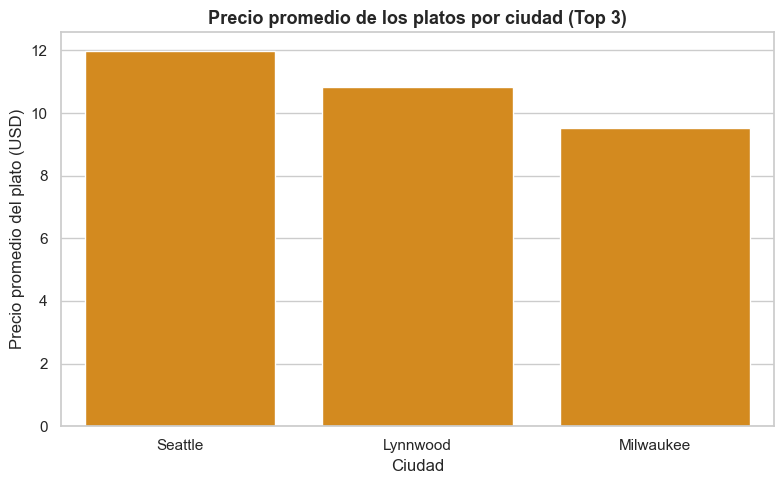

In [21]:
# 📊 Gráfico: barras comparativas
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_precio_ciudad, x="ciudad", y="precio_promedio_plato", color="#F18F01", ax=ax)
ax.set_title("Precio promedio de los platos por ciudad (Top 3)", fontsize=13, fontweight="bold")
ax.set_xlabel("Ciudad")
ax.set_ylabel("Precio promedio del plato (USD)")
plt.tight_layout()
plt.show()


**Conclusión para el CEO:** comer en Seattle cuesta en promedio $11.98 por plato, un 26% más caro que en Milwaukee ($9.53); Lynnwood queda en un punto intermedio ($10.82). **Recomendación:** en Seattle conviene una estrategia de menú premium orientada a margen, mientras que en Milwaukee conviene competir con tickets bajos y alto volumen — no tiene sentido replicar la misma estructura de precios en las dos ciudades.

### 4️⃣ La pregunta del millón: correlación precio-calidad

**¿Un restaurante más caro garantiza una mejor experiencia (score)?**


In [22]:
query_4 = """
SELECT rango_de_precios, ROUND(AVG(score), 2) AS score_promedio
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY score_promedio DESC;
"""

df_precio_calidad = pd.read_sql(text(query_4), conn)
print(query_4)
df_precio_calidad



SELECT rango_de_precios, ROUND(AVG(score), 2) AS score_promedio
FROM master_food_data
GROUP BY rango_de_precios
ORDER BY score_promedio DESC;



,rango_de_precios,score_promedio
0,None,4.63
1,Moderadamente caro,4.62
2,Económico,4.61
3,Caro,4.43


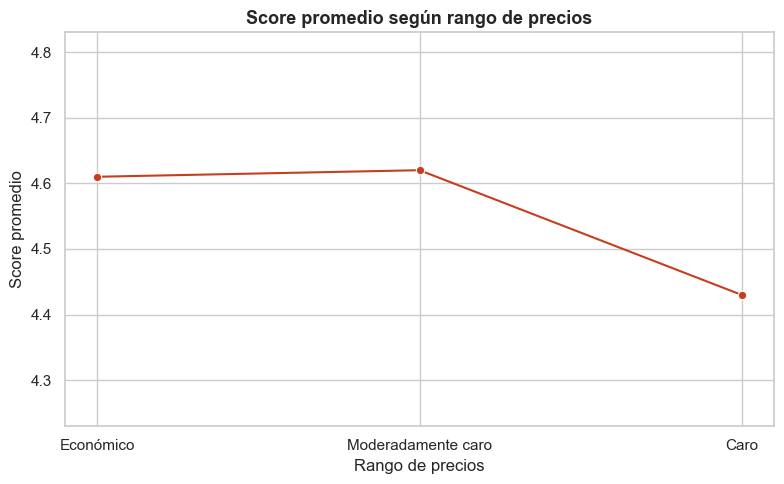

In [23]:
# 📊 Gráfico: barras / línea para mostrar la relación precio-calidad
orden_precio = ["Económico", "Moderadamente caro", "Caro", "Muy caro"]
df_precio_calidad["rango_de_precios"] = pd.Categorical(
    df_precio_calidad["rango_de_precios"], categories=orden_precio, ordered=True
)
df_precio_calidad = df_precio_calidad.sort_values("rango_de_precios")

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_precio_calidad, x="rango_de_precios", y="score_promedio", marker="o", color="#C73E1D", ax=ax)
ax.set_title("Score promedio según rango de precios", fontsize=13, fontweight="bold")
ax.set_xlabel("Rango de precios")
ax.set_ylabel("Score promedio")
ax.set_ylim(df_precio_calidad["score_promedio"].min() - 0.2, df_precio_calidad["score_promedio"].max() + 0.2)
plt.tight_layout()
plt.show()


**Conclusión para el CEO:** el score se mantiene casi idéntico entre Económico (4.61) y Moderadamente caro (4.62), y cae en Caro (4.43) — pagar más no solo no mejora la experiencia, en este mercado la empeora levemente. **Recomendación:** no vale la pena posicionar la marca como premium para "comprar" mejor percepción de calidad; conviene invertir ese presupuesto en operación (tiempos de entrega, empaque, atención) en vez de en el precio del menú.

In [25]:
conn.close()


---
## ✅ Cierre

El pipeline ETL quedó materializado en `delivery_insights.db` (tabla `master_food_data`), lista
para que el equipo de BI siga explotándola. Los 4 hallazgos anteriores resumen la posición
competitiva del mercado y sirven de base para decidir en qué ciudad invertir primero.
